In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_one(hp_search, methods, x_metric, save):
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    for i, y_metric in enumerate(["post_transfer_poverty_rate", "post_transfer_poverty_gap"]):
        for hp in hp_search:
            if hp == "gan":
                color = "purple"
            elif hp == "gt":
                color = "green"
            elif hp == "default":
                color = "pink"
            for method in methods:
                if hp in ["gan", "gt"]:
                    df = pd.read_csv(f"results/output_{hp}_{method}.csv")
                else:
                    df = pd.read_csv(f"results/{hp}_{method}.csv")
                ax[i].plot(df[x_metric], df[y_metric], label=f"{hp}_{method}", marker="o", color=color)
        ax[i].legend()
        ax[i].set_title(f"{y_metric} vs. {x_metric}")
        ax[i].set_xlabel(x_metric)
        ax[i].set_ylabel(y_metric)
        ax[i].legend()
    plt.suptitle(f"GAN vs. GT Comparison: {methods[0]}")
    plt.savefig(save, bbox_inches="tight")

def plot_all(hp_search, methods, x_metric, save):
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    for i, y_metric in enumerate(["post_transfer_poverty_rate", "post_transfer_poverty_gap"]):
        for hp in hp_search:
            for method in methods:
                if "rate" in method:
                    color = "blue"
                if "gap" in method:
                    color = "orange"
                if "continuous" in method:
                    linestyle = "solid"
                if "binary" in method:
                    linestyle = "dashed"
                    
                if hp in ["gan", "gt"]:
                    df = pd.read_csv(f"results/output_{hp}_{method}.csv")
                else:
                    df = pd.read_csv(f"results/{hp}_{method}.csv")
                ax[i].plot(df[x_metric], df[y_metric], label=f"{hp}_{method}", marker="o", color=color, linestyle=linestyle)
        ax[i].legend()
        ax[i].set_title(f"{y_metric} vs. {x_metric}")
        ax[i].set_xlabel(x_metric)
        ax[i].set_ylabel(y_metric)
        ax[i].legend()
    plt.suptitle(f"Learning Methods with {hp_search[0]}-selected HP")
    plt.savefig(save, bbox_inches="tight")

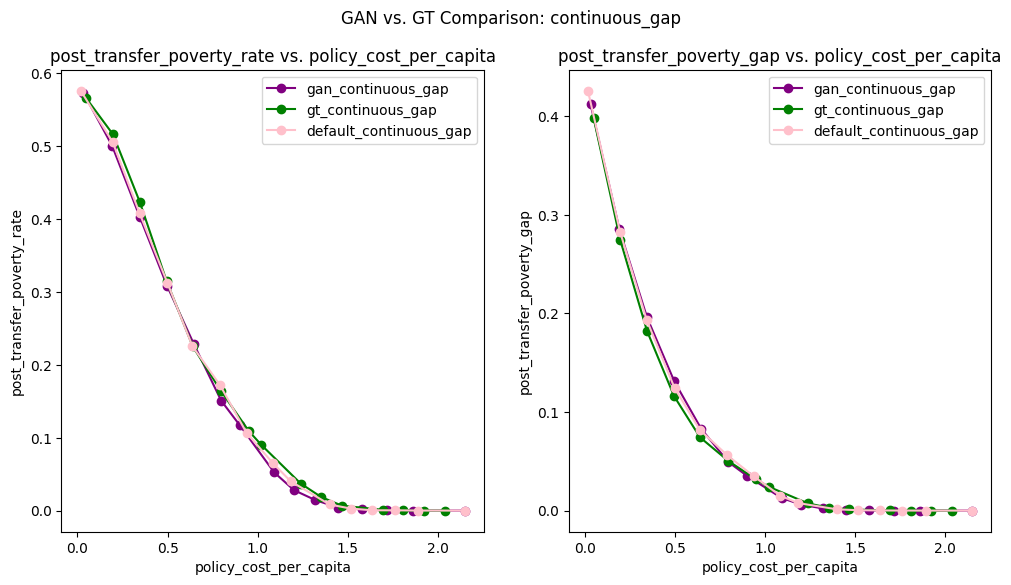

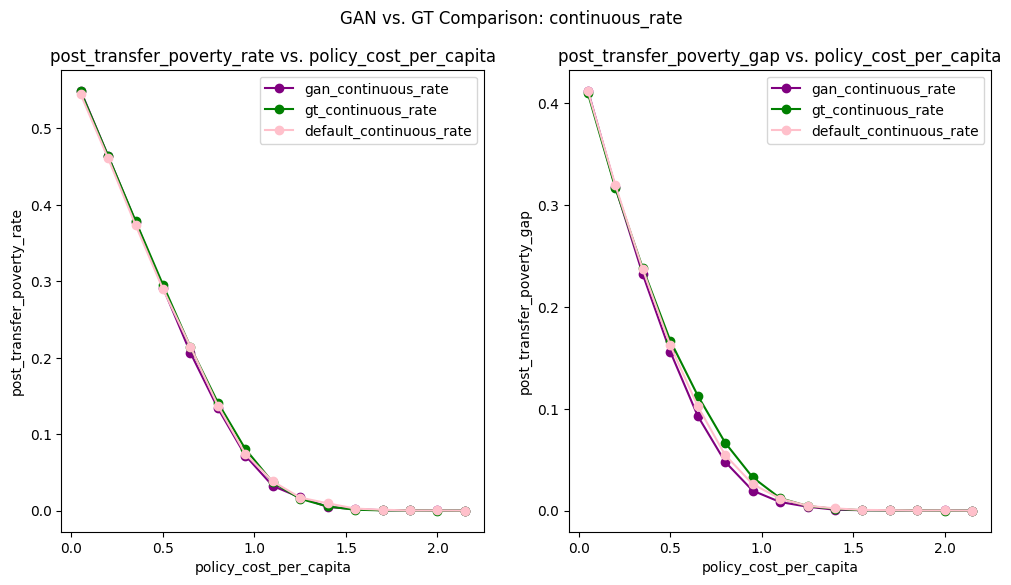

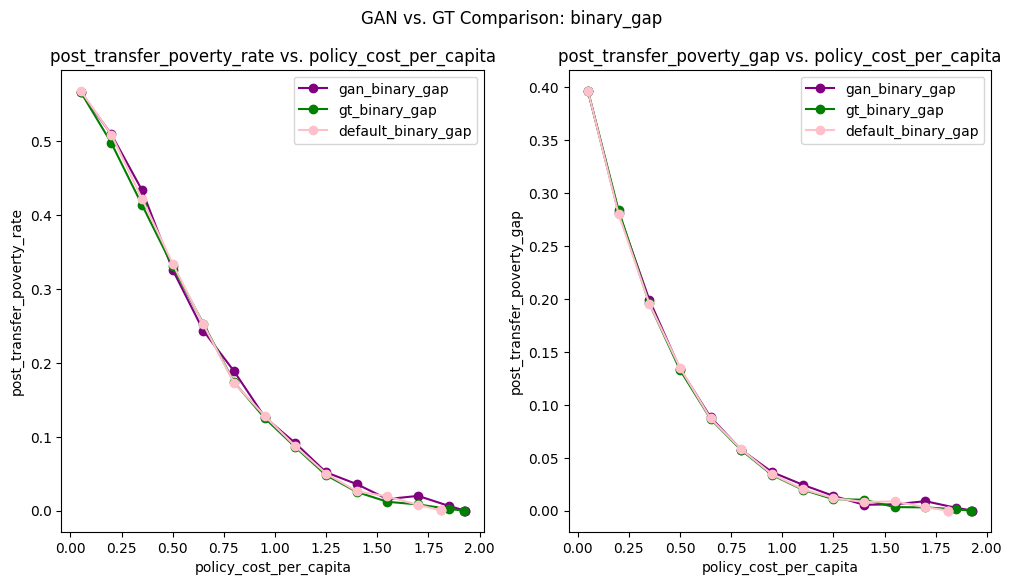

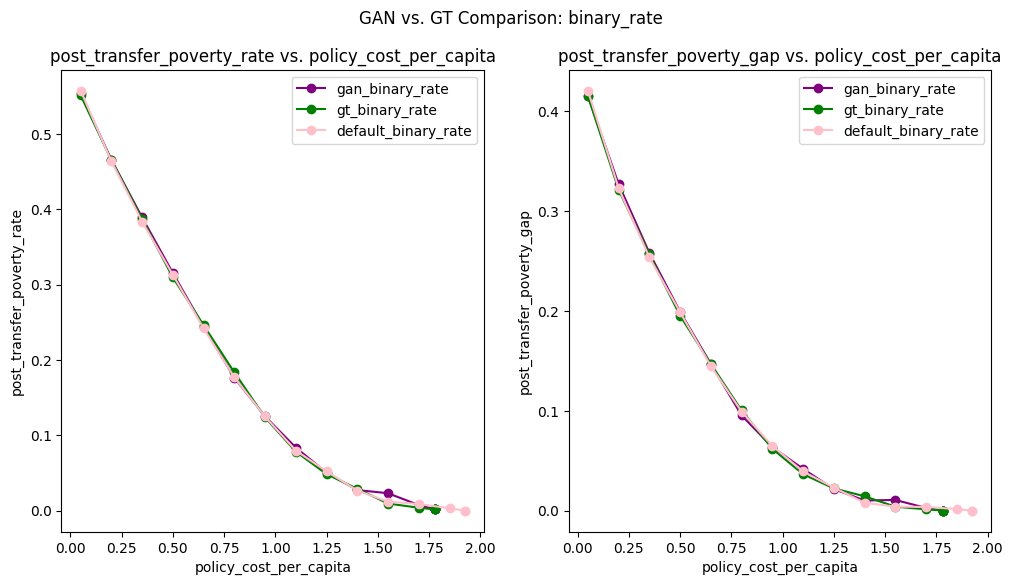

In [3]:
hp_search = ["gan", "gt", "default"]
for method in [ "continuous_gap", "continuous_rate", "binary_gap", "binary_rate"]:
    plot_one(hp_search, [method],  "policy_cost_per_capita", f"figs/hp_{method}.pdf")

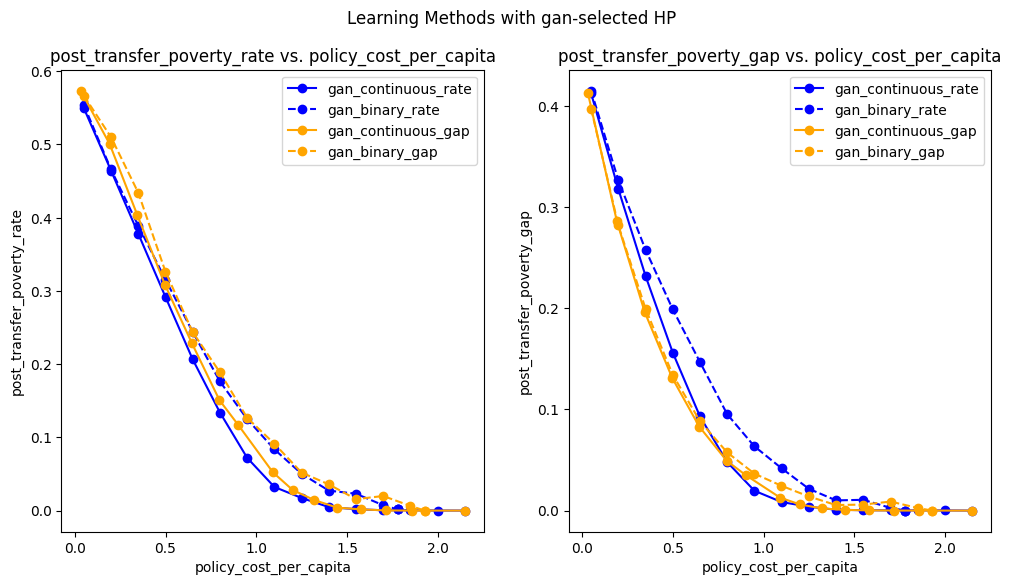

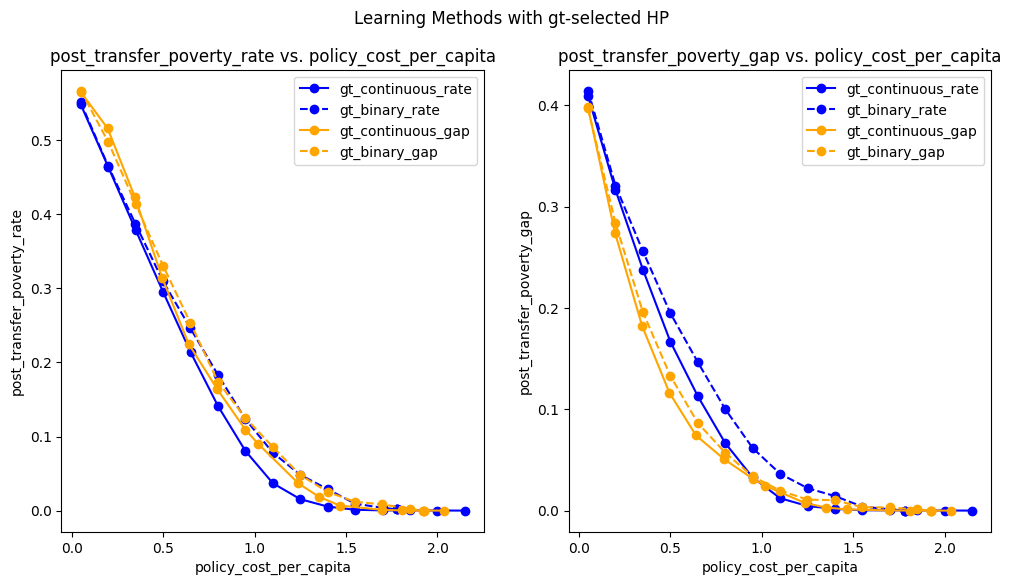

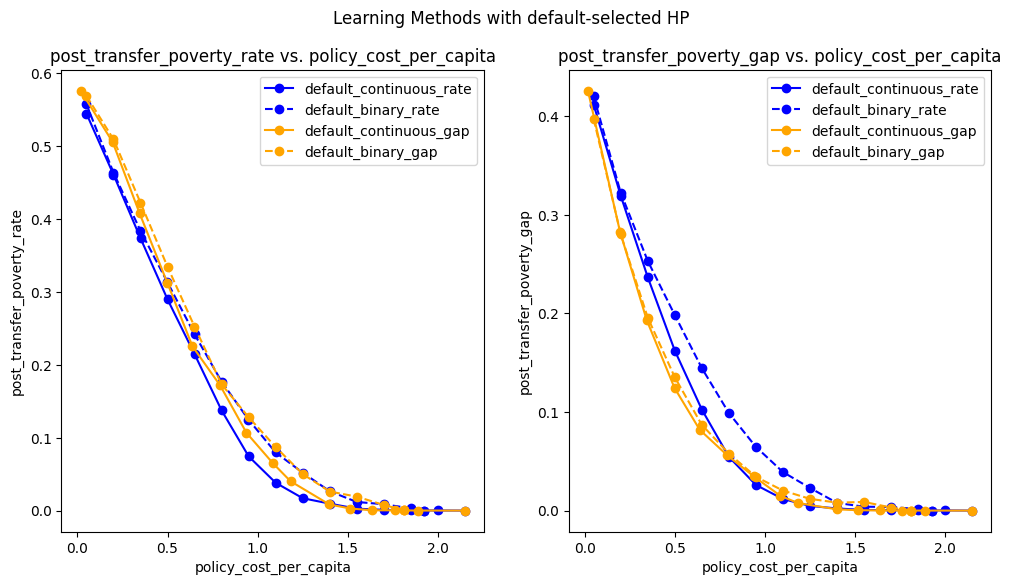

In [4]:
hp_search = ["gan", "gt", "default"]
methods = ["continuous_rate", "binary_rate", "continuous_gap", "binary_gap"]
for hp_search_approach in hp_search:
    plot_all([hp_search_approach], methods,  "policy_cost_per_capita", f"figs/{hp_search_approach}.pdf")